# FunnelIQ — Package 5: The Follow-Up Paradox

**The claim to test:** the sales manager says *"After the 3rd follow-up, we're just wasting
time."* Is that true?

**Deliverable:** the dropout rate at each follow-up stage (`followup_1` → `followup_5`),
visualized, plus a data-driven recommendation surfaced in the dashboard.

**Questions the brief asks us to answer:**
1. At which stage does dropout behave unexpectedly?
2. For deals that eventually closed, how many follow-ups did they typically take?
3. Should Northbound change its follow-up policy — yes or no, and why?

**This package is purely descriptive** -- no held-out target, no model. Per
[`funneliq_leakage_decisions.md`](./funneliq_leakage_decisions.md): *"Package 5 legitimately uses
`closed` to study which follow-up stage matters, because you're describing what happened, not
forecasting it."* The leakage rule that governs Packages 2-4 doesn't apply here the same way.


## 1. Understanding the funnel structure first

Before computing a "dropout rate," it's worth confirming exactly what these columns represent
and how they relate -- the brief's column glossary says `followup_1`...`followup_5` are *"leads
remaining after each follow-up round,"* `closed` is deals won, `not_closed` is leads that went
through the funnel but didn't convert. Rather than assume, check the actual relationships.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("funnel_marketing_data.csv").drop_duplicates().reset_index(drop=True)
print(f"rows after dedupe: {len(df)}")

# Does the funnel monotonically shrink, row by row, with zero exceptions?
checks = {
    "leads_answered >= followup_1": (df["leads_answered"] >= df["followup_1"]),
    "followup_1 >= followup_2": (df["followup_1"] >= df["followup_2"]),
    "followup_2 >= followup_3": (df["followup_2"] >= df["followup_3"]),
    "followup_3 >= followup_4": (df["followup_3"] >= df["followup_4"]),
    "followup_4 >= followup_5": (df["followup_4"] >= df["followup_5"]),
}
for name, mask in checks.items():
    print(f"{name}: holds for {mask.sum()}/{len(df)} rows")


rows after dedupe: 3490
leads_answered >= followup_1: holds for 3490/3490 rows
followup_1 >= followup_2: holds for 3490/3490 rows
followup_2 >= followup_3: holds for 3490/3490 rows
followup_3 >= followup_4: holds for 3490/3490 rows
followup_4 >= followup_5: holds for 3490/3490 rows


In [2]:
# The key structural finding: does followup_5 == closed + not_closed, exactly?
identity_holds = (df["followup_5"] == (df["closed"] + df["not_closed"]))
print(f"followup_5 == closed + not_closed: holds for {identity_holds.sum()}/{len(df)} rows")
(df["followup_5"] - (df["closed"] + df["not_closed"])).describe()


followup_5 == closed + not_closed: holds for 3490/3490 rows


count    3490.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

**This is an exact identity, zero exceptions across all 3,490 rows** -- not an approximation.
The practical meaning: in this dataset, a lead's outcome (`closed` or `not_closed`) is only ever
resolved from the pool of leads still active after **all five** follow-up rounds. Nothing in the
data distinguishes "closed after round 2" from "closed after round 5" -- every close is counted
against the `followup_5` survivor pool. This will matter directly for Question 2 below, and it's
worth stating as an assumption/caveat about the dataset rather than a claim about real-world
sales behavior: it may reflect how this dataset was recorded or generated, not necessarily proof
that no one in reality ever closes early.


## 2. Dropout rate at each stage

**Method**: aggregate (sum of leads lost at a stage, divided by sum of leads entering that
stage) across the whole dataset, rather than averaging each row's individual percentage. Summing
first avoids letting small campaigns with tiny denominators (e.g. a campaign with only 4
`leads_answered`) swing the average disproportionately -- the aggregate rate answers "what
fraction of all leads that reached this stage dropped out," weighted by actual lead volume.


In [3]:
stages = [
    ("Initial: no answer", df["leads_not_answered"].sum(), df["num_leads"].sum()),
    ("Stage 1 (answered -> after FU1)", (df["leads_answered"] - df["followup_1"]).sum(), df["leads_answered"].sum()),
    ("Stage 2 (after FU1 -> after FU2)", (df["followup_1"] - df["followup_2"]).sum(), df["followup_1"].sum()),
    ("Stage 3 (after FU2 -> after FU3)", (df["followup_2"] - df["followup_3"]).sum(), df["followup_2"].sum()),
    ("Stage 4 (after FU3 -> after FU4)", (df["followup_3"] - df["followup_4"]).sum(), df["followup_3"].sum()),
    ("Stage 5 (after FU4 -> after FU5)", (df["followup_4"] - df["followup_5"]).sum(), df["followup_4"].sum()),
]

stage_df = pd.DataFrame(stages, columns=["stage", "dropped", "entering"])
stage_df["dropout_rate"] = stage_df["dropped"] / stage_df["entering"]
stage_df


,stage,dropped,entering,dropout_rate
0,Initial: no answer,63757,161600,0.394536
1,Stage 1 (answered -> after FU1),21268,97843,0.217369
2,Stage 2 (after FU1 -> after FU2),19659,76575,0.256729
3,Stage 3 (after FU2 -> after FU3),10593,56916,0.186116
4,Stage 4 (after FU3 -> after FU4),4806,46323,0.103750
5,Stage 5 (after FU4 -> after FU5),12133,41517,0.292242


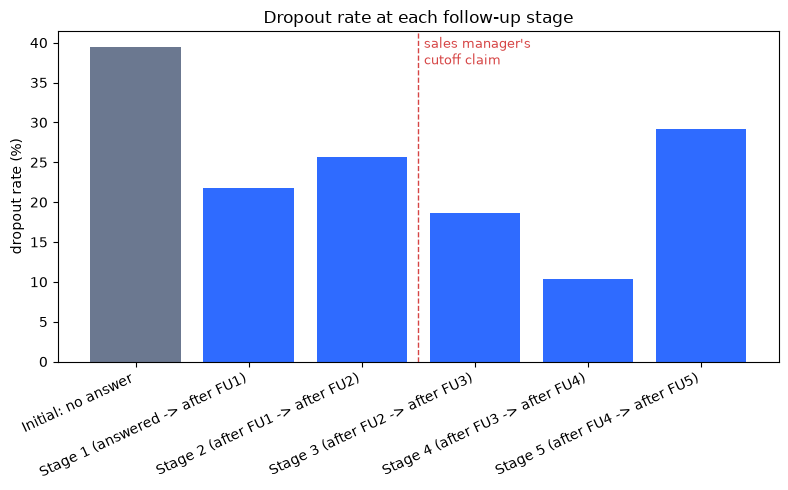

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#6b7890"] + ["#2f6bff"] * 5
ax.bar(stage_df["stage"], stage_df["dropout_rate"] * 100, color=colors)
ax.set_ylabel("dropout rate (%)")
ax.set_title("Dropout rate at each follow-up stage")
ax.axvline(2.5, color="#d64545", linestyle="--", linewidth=1)
ax.text(2.55, ax.get_ylim()[1] * 0.9, "sales manager's\ncutoff claim", color="#d64545", fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


**Reading this:** the pattern is not the smooth "increasingly wasteful" curve the sales manager's
claim implies. After the initial answer/no-answer split (39.5% never pick up at all -- the
biggest single drop in the whole funnel, and it happens before any follow-up even starts), the
follow-up-stage dropout rates are 21.7%, 25.7%, 18.6%, **10.4%**, then a jump back up to 29.2%.

**Answering Question 1 -- which stage behaves unexpectedly:** Stage 4 (the transition right
after the 3rd follow-up call, i.e. from `followup_3` to `followup_4`) has the **lowest** dropout
of any stage in the whole sequence -- 10.4%, well below stages 1-3. That's the opposite of what
the sales manager's claim predicts: leads who are still engaged after 3 follow-ups are actually
the *stickiest* group, most likely to stay engaged for a 4th. The real anomaly is **Stage 5**
(after the 4th follow-up, heading into the 5th) -- dropout nearly triples back up to 29.2%, the
second-highest rate in the sequence.


## 3. For deals that closed, how many follow-ups did it typically take?



In [5]:
total_answered = df["leads_answered"].sum()
total_fu5 = df["followup_5"].sum()
total_closed = df["closed"].sum()
total_not_closed = df["not_closed"].sum()

print(f"leads_answered (start of follow-up funnel): {total_answered}")
print(f"survive to followup_5: {total_fu5} ({total_fu5/total_answered:.1%} of answered)")
print(f"eventually closed: {total_closed} ({total_closed/total_answered:.1%} of answered, {total_closed/total_fu5:.1%} of followup_5 survivors)")
print(f"not_closed: {total_not_closed} ({total_not_closed/total_fu5:.1%} of followup_5 survivors)")


leads_answered (start of follow-up funnel): 97843
survive to followup_5: 29384 (30.0% of answered)
eventually closed: 10557 (10.8% of answered, 35.9% of followup_5 survivors)
not_closed: 18827 (64.1% of followup_5 survivors)


Given Section 1's identity, the honest, data-grounded answer is: **every recorded close in this
dataset comes from the pool of leads that completed all five follow-up rounds** -- there is no
"closed after 2 follow-ups" case represented anywhere in the data. Of the leads who make it all
the way to `followup_5`, only 36% close (64% still don't, even after five rounds of persistence)
-- so surviving to the end is necessary but far from sufficient. Overall, about 10.8% of all
answered leads eventually become a closed deal, and 100% of them needed the full sequence to get
there.

**Caveat, stated plainly**: this conclusion follows from how outcomes are recorded in this
dataset (Section 1's identity), not from directly observing which follow-up call preceded each
individual sale. It's the strongest answer the data actually supports, but it doesn't rule out
that some real-world deals close earlier and this dataset simply doesn't capture that detail.


## 4. Should Northbound change its follow-up policy?

**No — if anything, the data argues against cutting follow-ups short, not for it.** Two
independent pieces of evidence, both against the sales manager's claim:

1. **Dropout is lowest, not highest, right after the 3rd follow-up** (Section 2) -- leads who
   stick around that long are the most engaged group in the whole funnel, not the least.
2. **Every recorded close required completing all five rounds** (Section 3) -- stopping after
   follow-up 3 would forfeit 100% of this dataset's closed deals, since none of them are recorded
   as resolved before `followup_5`.

If there's a real opportunity here, it's the opposite of the manager's instinct: **Stage 5** (the
jump from `followup_4` to `followup_5`, 29.2% dropout) is where the real leak is -- worth
investigating *why* engaged leads suddenly drop right before the funnel resolves, rather than
cutting the process short earlier where it's actually working.


## 5. What goes in the dashboard

The brief asks for this "visualized... surfaced in the dashboard." Since this package is
descriptive (no model, no live per-customer prediction), the dashboard gets a static summary
panel: the same dropout-by-stage chart as Section 2, plus the recommendation from Section 4,
added directly to `static/index.html` -- see the "Follow-up dropout analysis" section there.
